In [18]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [19]:
import liana as li
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from shapely.geometry import Polygon

In [20]:
import ipympl 
%matplotlib widget

In [21]:
import matplotlib
print(matplotlib.get_backend())

widget


# Data Prep

In [22]:
# Info
whatFer = "one" # "one" or  "two"

#Load data
base_folder = Path(f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/{whatFer}fer/")
adata_file = base_folder / f"{whatFer}fer.h5ad"
out_figs = base_folder / "figures"


ST_sample = sc.read_h5ad(adata_file)

In [23]:
# COMPUTER
HNE_TIF_PATHS = {
    "F07839": Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/data/images_for_alignments/121724-121924_RL_mRT_TMA4_1_TMA5_1/hne/121724_RL_mRT_TMA4_Slide_1.tif"),
    "F07840": Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/data/images_for_alignments/121724-121924_RL_mRT_TMA4_1_TMA5_1/hne/121724_RL_mRT_TMA5_Slide_1.tif")
}



## Library selection

In [24]:
sample_name = "RTCyPSCA_1_4"

lib_id = "F07839"
adata = ST_sample[ST_sample.obs['mouse']=="RTCyPSCA_1_4"].copy()

## Merging polygons

In [25]:
# segmentation_path = Path("/mnt/c/Users/jonan/Documents/1Work/Roselab/Spatial/CAR_T/data/cell_segmentation/")
# gdf_file = segmentation_path /  "concatenated" / "combined_nuclei_geometry.gpkg"
# geo_file = gpd.read_file(gdf_file)

# gdf = geo_file.merge(adata.obs[['id', 'n_counts']], on='id', how='inner')

# LIANA

In [26]:
li.ut.spatial_neighbors(adata, bandwidth=40, cutoff = 0.1, kernel='gaussian', set_diag=True)
lr = li.mt.bivariate(adata,
                resource_name='mouseconsensus', # NOTE: uses HUMAN gene symbols!
                local_name='cosine', # Name of the function
                global_name="morans", # Name global function
                n_perms=100, # Number of permutations to calculate a p-value
                mask_negatives=False, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.05, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=False
                )

/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


## Selection

In [27]:
pair = "Spp1^Cd44"
thresh = 0.30

In [28]:
# If you want to see all the possible pairs lr.var_names

In [29]:

vals = lr[:, pair].X.toarray().ravel
# keep = lr[:,pair].X.toarray().ravel() > thresh
coords = lr.obsm["spatial"]
selected = np.zeros(coords.shape[0], dtype=bool) # place holder for the future lasso selection


# Testing

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))

sc.pl.spatial(
    lr,
    color=[pair],
    size=0.3,
    cmap="magma",
    library_id=lib_id,
    img_key="hires",
    show=True,
    ax=ax,
    alpha=0.5   
)



In [ ]:
'spatial' in lr.uns, list(lr.uns.get('spatial', {}).keys())

In [ ]:
lr.obsm["spatial"]

In [95]:
np.zeros(coords.shape[0], dtype=bool)

array([False, False, False, ..., False, False, False])

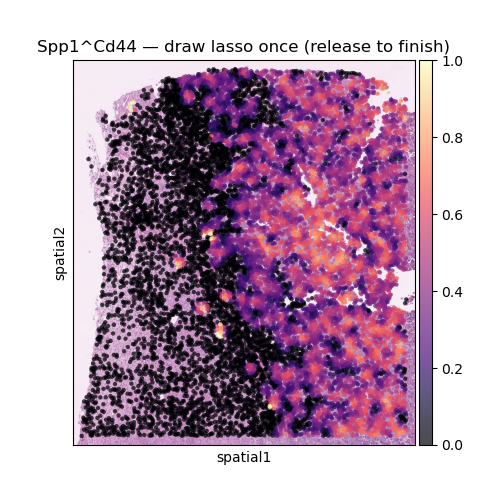

No lasso made — nothing selected.


In [31]:
import numpy as np
from matplotlib.path import Path
from matplotlib.widgets import LassoSelector

coords = lr.obsm["spatial"]                       # (n, 2)
xmin, xmax = coords[:,0].min(), coords[:,0].max()
ymin, ymax = coords[:,1].min(), coords[:,1].max()
m = 100
crop = (int(xmin-m), int(ymin-m), int(xmax+m), int(ymax+m))

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sq.pl.spatial_scatter(
    lr, color=pair, size=0.5, cmap="magma",
    library_id=lib_id, img_res_key="hires",
    crop_coord=crop, alpha=0.7, fig=fig, ax=ax, return_ax=False
)
ax.invert_yaxis()
ax.set_title(f"{pair} — draw lasso once (release to finish)")

selected = np.zeros(coords.shape[0], dtype=bool)

def onselect(verts):
    data_verts = ax.transData.inverted().transform(verts)
    path = Path(data_verts)
    selected[:] = path.contains_points(coords)
    # one-shot behavior:
    lasso.set_active(False)
    plt.close(fig)

lasso = LassoSelector(ax, onselect, useblit=True, button=[1])

plt.show(block=True)

if not selected.any():
    print("No lasso made — nothing selected.")
else:
    print(f"Selected cells: {selected.sum()} / {len(selected)}")
    selected_ids = lr.obs.index[selected]


In [32]:
selected.sum()

0

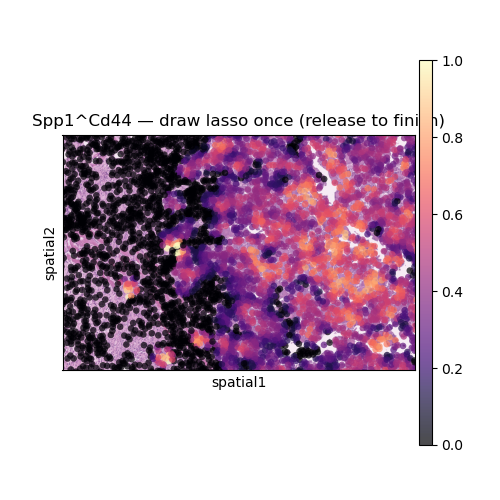

No lasso made — nothing selected.


In [26]:
# IMPORTANT: in scripts, block=True so you can interact before code continues
plt.show(block=True)

if not selected.any():
    print("No lasso made — nothing selected.")
else:
    print(f"Selected cells: {selected.sum()} / {len(selected)}")
    selected_ids = lr.obs.index[selected]

In [155]:

def onselect(verts):
    global selected
    path = Path(verts)
    selected = path.contains_points(coords)

lasso = LassoSelector(ax, onselect)
plt.show()

if not selected.any():
    selected[:] = True

In [94]:
coords

ArrayView([[7633.13077651, 1814.59292796],
           [7220.38707188, 1872.44502588],
           [6548.6821803 , 1817.14246692],
           ...,
           [7515.25484171, 1842.3771797 ],
           [7739.08991451, 1874.6019817 ],
           [7608.11279683, 1922.13250662]])

In [67]:
coords

ArrayView([[7633.13077651, 1814.59292796],
           [7220.38707188, 1872.44502588],
           [6548.6821803 , 1817.14246692],
           ...,
           [7515.25484171, 1842.3771797 ],
           [7739.08991451, 1874.6019817 ],
           [7608.11279683, 1922.13250662]])

/tmp/ipykernel_9441/1977042456.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


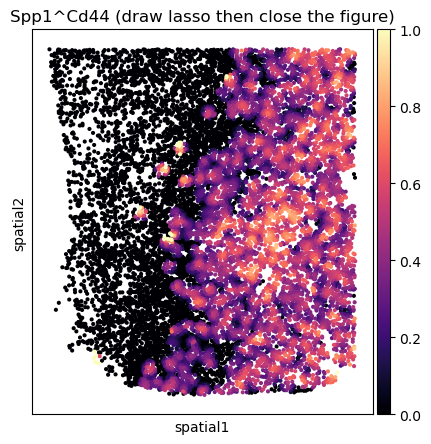

In [71]:
selected = np.zeros(coords.shape[0], dtype=bool)

fig, ax = plt.subplots(figsize=(5,5))
sc.pl.spatial(lr, color=[pair], size=0.5, cmap="magma",
              library_id=lib_id, img_key=None, show=False, ax=ax)
ax.set_title(f"{pair} (draw lasso then close the figure)")

def onselect(verts):
    global selected
    path = Path(verts)
    selected = path.contains_points(coords)

lasso = LassoSelector(ax, onselect)
plt.show()

# After closing the window, `selected` is your lasso mask
if not selected.any():
    # If you didn't draw, treat all as selected
    selected = np.ones(coords.shape[0], dtype=bool)


# Testing

In [26]:
gdf_file = segmentation_path /  "concatenated" / "combined_nuclei_geometry.gpkg"
geo_file = gpd.read_file(gdf_file)

In [ ]:
gdf = geo.merge(ST_sample.obs[['id', 'n_counts']], on='id', how='inner')

In [21]:
ST_sample.uns['spatial'].keys()

dict_keys(['F07839', 'F07840'])

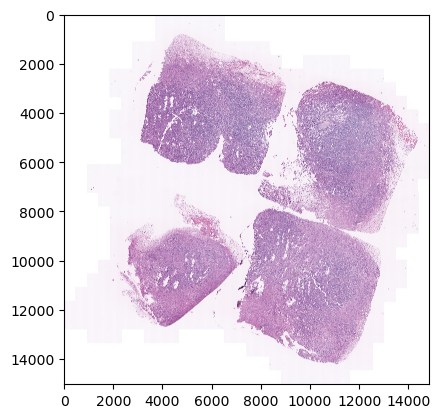

In [23]:
img = ST_sample.uns["spatial"]["F07840"]["images"]["hires"]

plt.imshow(img)
# plt.axis("off")
plt.show()

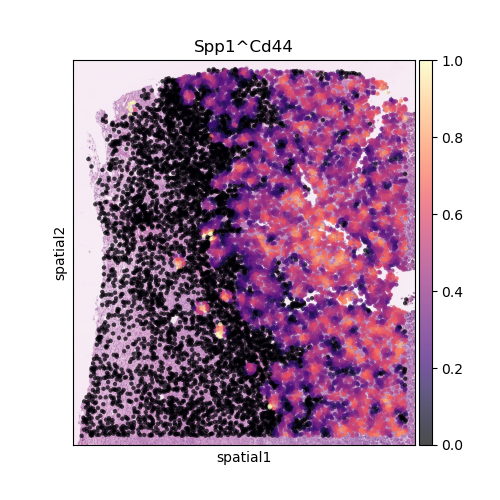

In [34]:
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path

coords = lr.obsm["spatial"]
fig, ax = plt.subplots(figsize=(5,5))
sq.pl.spatial_scatter(lr, color=pair, size=0.5, cmap="magma",
                      library_id=lib_id, img_res_key="hires",
                      crop_coord=crop, alpha=0.7, fig=fig, ax=ax, return_ax=False)
ax.invert_yaxis()

selected = np.zeros(coords.shape[0], bool)  # lives in kernel after cell ends

def onselect(verts):
    path = Path(verts)
    selected[:] = path.contains_points(ax.transData.transform(coords))
    print("Picked:", selected.sum())
    lasso.set_active(False)

lasso = LassoSelector(ax, onselect, useblit=False, button=[1])
